In [1]:
#%%capture
#%tensorflow_version 2.x
!pip install tensorflow==2.9.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.8/511.8 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 63.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 78.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.7/438.7 kB 29.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 86.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 781.3/781.3 kB 41.0 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.5.0
    Uninstalling keras-3.5.0:
      Successfully uninstalled keras-3.5.0
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 24.3.25
    Uninstalling flatbuffers-24.3.25:
      Successfully uninstalled flatbuffers-24.3.25
  Attempting uninstall: tensorboard-data-serve

In [1]:
import tensorflow as tf
!python --version                     # mostrar version de python
print('Tensorflow ' + tf.__version__) # mostrar version tensorflow

Python 3.10.12
Tensorflow 2.9.2


In [2]:
import os, subprocess

# Montar Google Drive y crear carpetas
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

work_dir = '/content/work_dir'                    # directorio de trabajo en local (mas rapido)
dwld_dir = '/content/gdrive/My Drive/dwld_dir'    # directorio de descarga en Google drive personal
subprocess.call(["mkdir","-p",work_dir])          # crear directorio para trabajo
subprocess.call(["mkdir","-p",dwld_dir+'/dataset/'])  # crear directorio para dataset

os.chdir(dwld_dir+'/dataset/')                        # posicionarse en el directorio
# Descargar dataset scenes15 si no esta disponible
if os.path.isfile('./dataset_scenes15.zip') == False:
  !wget http://www-vpu.eps.uam.es/~jcs/tsv/dataset_scenes15.zip

# Copiar el dataset al directorio local (mayor velocidad de lectura que en Gdrive)
!cp /content/gdrive/My\ Drive/dwld_dir/dataset/dataset_scenes15.zip /content/work_dir/

os.chdir(work_dir)                        # posicionarse en el directorio
if os.path.isdir('./scenes15') == False:
  !unzip -o -q dataset_scenes15.zip -d .

print('El dataset se encuentra descargado en el directorio {} \ny descomprimido en el directorio {} (usado para lectura de datos)'.format(dwld_dir, work_dir))

Mounted at /content/gdrive
El dataset se encuentra descargado en el directorio /content/gdrive/My Drive/dwld_dir 
y descomprimido en el directorio /content/work_dir (usado para lectura de datos)


In [10]:
# esta directiva genera un fichero con el codigo escrito a continuacion
import tensorflow as tf
import pathlib
import numpy as np

def crear_generadores(batch_size, img_height, img_width, horizontal_flip, rotation_range, width_shift_range,zoom_range):
    dataset_dir = pathlib.Path(work_dir + '/scenes15/')

    # Obtener etiquetas de clase y numero de clases
    CLASS_NAMES = np.array([item.name for item in dataset_dir.glob('*')]) #clases son subdirectorios de '/train/'
    NUM_CLASSES = len(CLASS_NAMES) # numero total de clases

    train_img_gen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255, validation_split=0.20, horizontal_flip=horizontal_flip, rotation_range=rotation_range,
                                                              width_shift_range= width_shift_range, zoom_range=zoom_range)
    test_img_gen = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1./255, validation_split=0.20)

    # Obtenemos un iterador sobre los datos de entrenamiento del dataset
    # aplicando el ImageDataGenerator creado anteriormente
    BATCH_SIZE = batch_size # numero de elementos procesados conjuntamente en cada iteracion
    IMG_HEIGHT = img_height
    IMG_WIDTH = img_width
    IMG_CHANNELS = 3
    train_data_gen = train_img_gen.flow_from_directory(directory=str(dataset_dir),
                                              target_size=(IMG_HEIGHT, IMG_WIDTH),
                                              color_mode='rgb',
                                              classes = list(CLASS_NAMES),
                                              class_mode='categorical',
                                              batch_size=BATCH_SIZE,
                                              subset="training",
                                              shuffle=True,
                                              seed=0)

    test_data_gen = test_img_gen.flow_from_directory(directory=str(dataset_dir),
                                              target_size=(IMG_HEIGHT, IMG_WIDTH),
                                              color_mode='rgb',
                                              classes = list(CLASS_NAMES),
                                              class_mode='categorical',
                                              batch_size=BATCH_SIZE,
                                              subset="validation",
                                              shuffle=True,
                                              seed=0)

    return train_data_gen, test_data_gen, NUM_CLASSES

In [4]:
# esta directiva genera un fichero con el codigo escrito a continuacion
import tensorflow.keras.layers as layers
import tensorflow.keras.models as models
import tensorflow.keras.optimizers as optimizers

def generar_red(num_classes, img_height, img_width, learning_rate, activation_function='relu', img_channels=3):

    # definir modelo de red
    model = models.Sequential()

    # incluir capa convolucional C1
    model.add(layers.Conv2D(filters=6,
                          kernel_size=(3, 3),
                          strides = (1,1),
                          padding = 'valid',
                          activation=activation_function,
                          input_shape=(img_height,img_width,img_channels)))

    # incluir average pooling S2
    model.add(layers.AveragePooling2D())

    # incluir capa convolucional C3
    model.add(layers.Conv2D(filters=16,
                          kernel_size=(3, 3),
                          strides = (1,1),
                          padding = 'valid',
                          activation=activation_function))

    # incluir average pooling S4
    model.add(layers.AveragePooling2D())

    # convertir el volumen de datos en vector fila para conectarlo con capa FC
    model.add(layers.Flatten())

    # incluir fully convolutional F5
    model.add(layers.Dense(units=120, activation=activation_function))

    # incluir fully convolutional F6
    model.add(layers.Dense(units=84, activation=activation_function))

    # incluir salida OUTPUT
    model.add(layers.Dense(units=num_classes, activation = 'softmax'))

    # definicion con optimizador con valores definidos por el usuario
    model.compile(optimizer=optimizers.SGD(learning_rate=learning_rate),
                loss='categorical_crossentropy',
                metrics=['accuracy'])

    return model

In [5]:
import time

def entrenamiento(model, batch_size, epochs, train_data_gen, test_data_gen, verbose=1):

    stime = time.time() # medida inicial de tiempo


    #si tiene problemas al ejecutar con la GPU,
    # descomente la siguiente linea para utilizar la CPU
    # y comente la linea que selecciona la GPU
    #with tf.device('/CPU:0'):
    with tf.device('/GPU:0'):
      history = model.fit_generator(
          generator=train_data_gen,
          steps_per_epoch=train_data_gen.n // batch_size,
          validation_data=test_data_gen,
          validation_steps=test_data_gen.n // batch_size,
          epochs=epochs,
          verbose=verbose
      )

    ftime = time.time() # medida final de tiempo
    #print('Entrenamiento terminado {} secs' .format(ftime-stime))

    return history, ftime-stime

In [6]:
import time

def test(tets_data_gen, batch_size, verbose):
    stime = time.time() # medida inicial de tiempo

    #si tiene problemas al ejecutar con la GPU,
    # descomente la siguiente linea para utilizar la CPU
    # y comente la linea que selecciona la GPU
    #with tf.device('/CPU:0'):
    with tf.device('/GPU:0'):
      test_loss, test_acc = model.evaluate_generator(generator=test_data_gen,
                                                    steps = test_data_gen.n // batch_size,
                                                    verbose=verbose)

    ftime = time.time() # medida final de tiempo
    #print('Test terminado {} secs' .format(ftime-stime))

    return test_loss, test_acc, ftime-stime

In [7]:
import matplotlib.pyplot as plt

def mostrar_resultados(history, title='Training and Validation Accuracy'):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    loss = history.history['loss']
    val_loss = history.history['val_loss']

    EPOCHS = len(acc)


    plt.figure(figsize=(8, 8))
    plt.subplot(2,1, 1)
    plt.plot(range(EPOCHS), acc, label='Rendimiento train (accuracy)')
    plt.plot(range(EPOCHS), val_acc, label='Rendimiento validacion (accuracy)')
    plt.legend(loc='upper left')
    plt.title(title)

    plt.subplot(2,1, 2)
    plt.plot(range(EPOCHS), loss, label='Pérdidas entrenamiento (Loss)')
    plt.plot(range(EPOCHS), val_loss, label='Pérdidas validacion (Loss)')
    plt.legend(loc='upper left')
    plt.title('Training and Validation Loss')
    plt.xlabel('# epoca')

    plt.show()

Found 3592 images belonging to 15 classes.
Found 893 images belonging to 15 classes.
Epoch 1/25


<ipython-input-5-0ca46b694a29>:13: UserWarning: `Model.fit_generator` is deprecated and will be removed in a future version. Please use `Model.fit`, which supports generators.
  history = model.fit_generator(


449/449 [==============================] - 10s 21ms/step - loss: 2.6962 - accuracy: 0.0955 - val_loss: 2.6842 - val_accuracy: 0.0912
Epoch 2/25
449/449 [==============================] - 8s 17ms/step - loss: 2.6749 - accuracy: 0.1027 - val_loss: 2.6613 - val_accuracy: 0.1194
Epoch 3/25
449/449 [==============================] - 10s 22ms/step - loss: 2.6237 - accuracy: 0.1406 - val_loss: 2.6146 - val_accuracy: 0.1318
Epoch 4/25
449/449 [==============================] - 8s 17ms/step - loss: 2.5127 - accuracy: 0.1804 - val_loss: 2.4924 - val_accuracy: 0.1971
Epoch 5/25
449/449 [==============================] - 10s 22ms/step - loss: 2.4000 - accuracy: 0.2230 - val_loss: 2.4457 - val_accuracy: 0.2050
Epoch 6/25
449/449 [==============================] - 9s 19ms/step - loss: 2.3230 - accuracy: 0.2430 - val_loss: 2.4274 - val_accuracy: 0.2196
Epoch 7/25
449/449 [==============================] - 8s 17ms/step - loss: 2.2724 - accuracy: 0.2584 - val_loss: 2.3418 - val_accuracy: 0.2342
Epoch 8

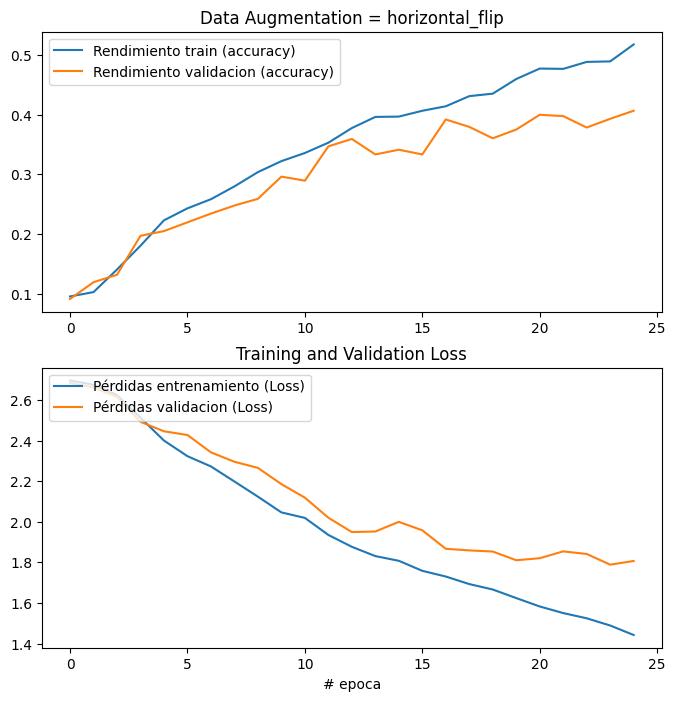

Found 3592 images belonging to 15 classes.
Found 893 images belonging to 15 classes.
Epoch 1/25
449/449 [==============================] - 13s 27ms/step - loss: 2.6805 - accuracy: 0.1036 - val_loss: 2.6464 - val_accuracy: 0.1306
Epoch 2/25
449/449 [==============================] - 15s 33ms/step - loss: 2.5984 - accuracy: 0.1392 - val_loss: 2.6012 - val_accuracy: 0.1351
Epoch 3/25
449/449 [==============================] - 13s 28ms/step - loss: 2.5382 - accuracy: 0.1695 - val_loss: 2.5381 - val_accuracy: 0.1610
Epoch 4/25
449/449 [==============================] - 12s 26ms/step - loss: 2.4726 - accuracy: 0.1849 - val_loss: 2.5517 - val_accuracy: 0.1791
Epoch 5/25
449/449 [==============================] - 13s 28ms/step - loss: 2.4196 - accuracy: 0.2035 - val_loss: 2.4681 - val_accuracy: 0.2128
Epoch 6/25
449/449 [==============================] - 12s 28ms/step - loss: 2.3656 - accuracy: 0.2308 - val_loss: 2.4343 - val_accuracy: 0.2252
Epoch 7/25
449/449 [==============================]

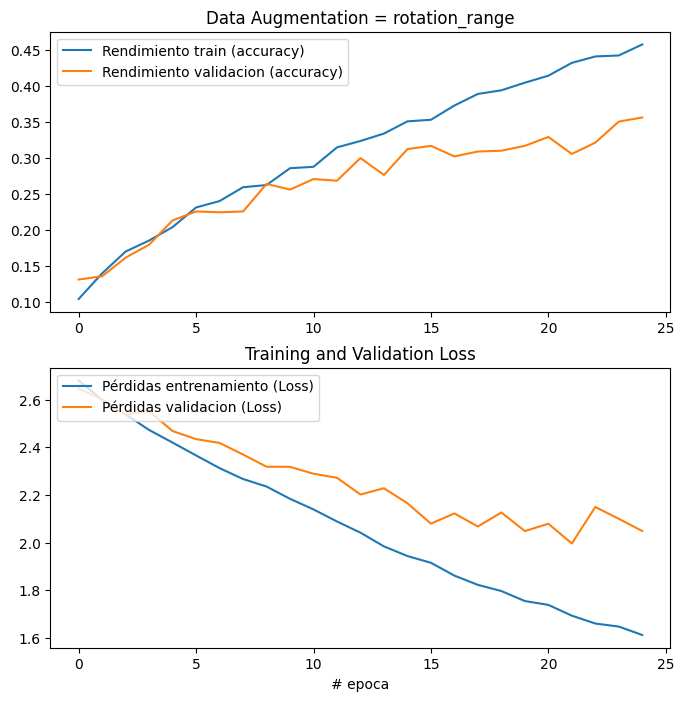

Found 3592 images belonging to 15 classes.
Found 893 images belonging to 15 classes.
Epoch 1/25
449/449 [==============================] - 14s 30ms/step - loss: 2.6877 - accuracy: 0.0841 - val_loss: 2.6728 - val_accuracy: 0.0845
Epoch 2/25
449/449 [==============================] - 11s 25ms/step - loss: 2.6580 - accuracy: 0.1052 - val_loss: 2.6350 - val_accuracy: 0.1306
Epoch 3/25
449/449 [==============================] - 12s 27ms/step - loss: 2.6072 - accuracy: 0.1336 - val_loss: 2.5910 - val_accuracy: 0.1475
Epoch 4/25
449/449 [==============================] - 12s 27ms/step - loss: 2.5365 - accuracy: 0.1615 - val_loss: 2.4981 - val_accuracy: 0.1813
Epoch 5/25
449/449 [==============================] - 12s 27ms/step - loss: 2.4690 - accuracy: 0.1860 - val_loss: 2.4934 - val_accuracy: 0.1982
Epoch 6/25
449/449 [==============================] - 10s 23ms/step - loss: 2.3899 - accuracy: 0.2227 - val_loss: 2.3361 - val_accuracy: 0.2286
Epoch 7/25
449/449 [==============================]

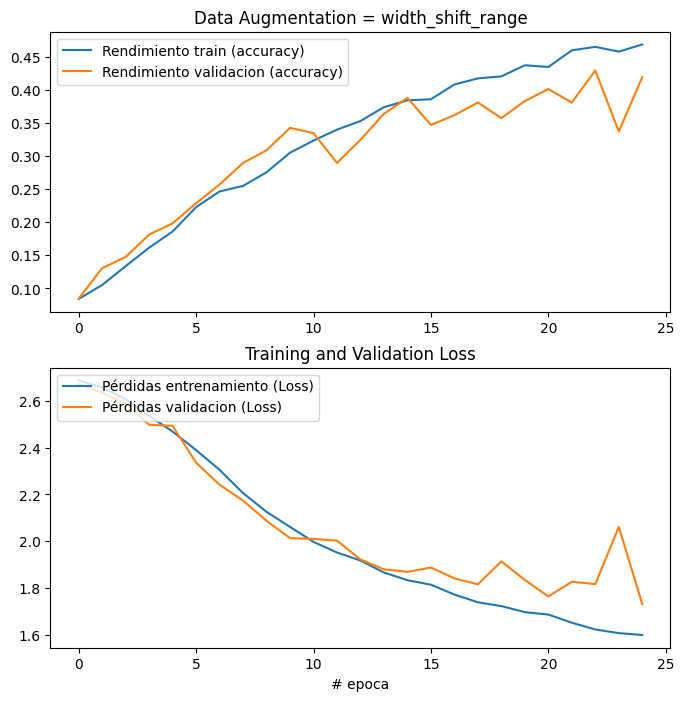

Found 3592 images belonging to 15 classes.
Found 893 images belonging to 15 classes.
Epoch 1/25
449/449 [==============================] - 14s 30ms/step - loss: 2.7007 - accuracy: 0.0871 - val_loss: 2.6874 - val_accuracy: 0.1115
Epoch 2/25
449/449 [==============================] - 13s 29ms/step - loss: 2.6613 - accuracy: 0.1139 - val_loss: 2.6237 - val_accuracy: 0.1059
Epoch 3/25
449/449 [==============================] - 13s 28ms/step - loss: 2.5740 - accuracy: 0.1528 - val_loss: 2.5752 - val_accuracy: 0.1509
Epoch 4/25
449/449 [==============================] - 13s 29ms/step - loss: 2.5003 - accuracy: 0.1787 - val_loss: 2.5200 - val_accuracy: 0.1520
Epoch 5/25
449/449 [==============================] - 12s 26ms/step - loss: 2.4449 - accuracy: 0.2035 - val_loss: 2.5163 - val_accuracy: 0.1869
Epoch 6/25
449/449 [==============================] - 13s 28ms/step - loss: 2.3805 - accuracy: 0.2216 - val_loss: 2.4274 - val_accuracy: 0.2196
Epoch 7/25
449/449 [==============================]

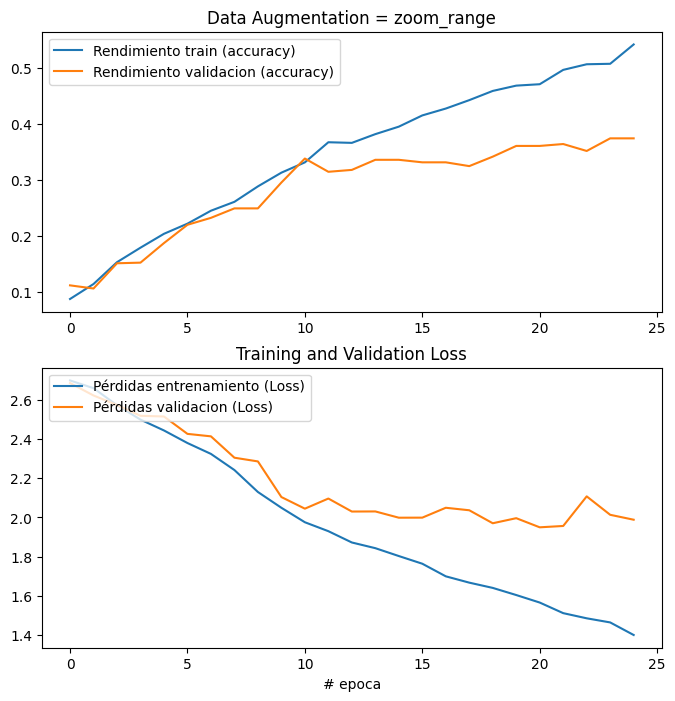

In [11]:
batch_size = 8
epochs = 25
img_size = 32
learning_rate = 0.01
#horizontal_flip, rotation_range, width_shift_range,zoom_range
data_augmentation_list = [(True, 0,0,0), (False,20, 0,0), (False,0,0.2,0), (False,0,0,0.2)]
data_augmentation_labels = ["horizontal_flip", "rotation_range", "width_shift_range","zoom_range"]
time_list = []
final_train_loss = []
final_train_acc = []
final_val_loss = []
final_val_acc = []

for horizontal_flip, rotation_range, width_shift_range,zoom_range in data_augmentation_list:
    train_data_gen, test_data_gen, num_classes = crear_generadores(batch_size, img_size, img_size, horizontal_flip, rotation_range, width_shift_range,zoom_range)
    model = generar_red(num_classes, img_size, img_size, learning_rate=learning_rate)
    history, train_time = entrenamiento(model, batch_size, epochs, train_data_gen, test_data_gen)
    # Pérdida y exactitud final de entrenamiento
    final_train_loss.append(history.history['loss'][-1])
    final_train_acc.append(history.history['accuracy'][-1])

    # Pérdida y exactitud final de validación
    final_val_loss.append(history.history['val_loss'][-1])
    final_val_acc.append(history.history['val_accuracy'][-1])
    time_list.append(train_time)
    mostrar_resultados(history, title='Data Augmentation = {}'.format(data_augmentation_labels[data_augmentation_list.index((horizontal_flip, rotation_range, width_shift_range,zoom_range))]))

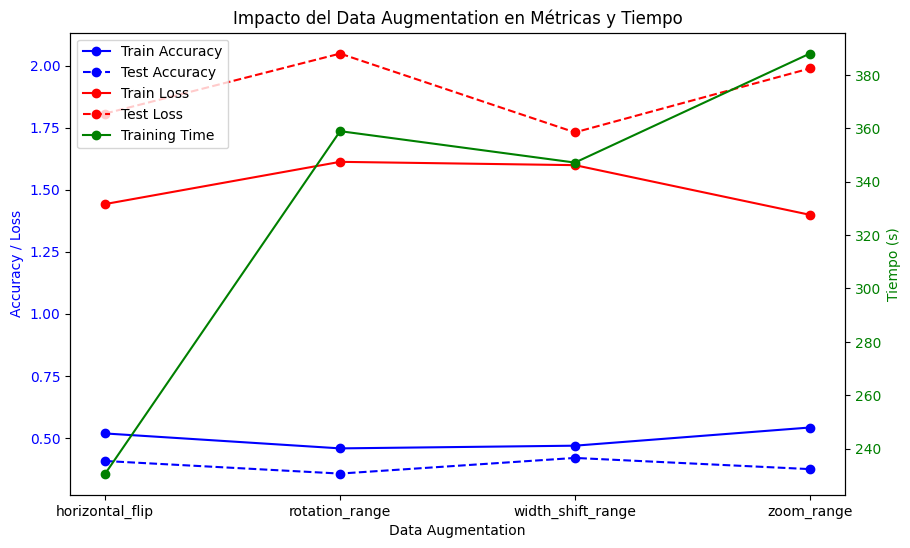

In [12]:
# Crear la figura y el eje principal
fig, ax1 = plt.subplots(figsize=(10, 6))

# Ejes principales para accuracy y loss
ax1.set_xlabel('Data Augmentation')
ax1.set_ylabel('Accuracy / Loss', color='blue')
ax1.plot(data_augmentation_labels, final_train_acc, marker='o', label='Train Accuracy', color='blue', linestyle='-')
ax1.plot(data_augmentation_labels, final_val_acc, marker='o', label='Test Accuracy', color='blue', linestyle='--')
ax1.plot(data_augmentation_labels, final_train_loss, marker='o', label='Train Loss', color='red', linestyle='-')
ax1.plot(data_augmentation_labels, final_val_loss, marker='o', label='Test Loss', color='red', linestyle='--')
ax1.tick_params(axis='y', labelcolor='blue')

# Ejes secundarios para tiempos de entrenamiento
ax2 = ax1.twinx()
ax2.set_ylabel('Tiempo (s)', color='green')
ax2.plot(data_augmentation_labels, time_list, marker='o', label='Training Time', color='green', linestyle='-')
ax2.tick_params(axis='y', labelcolor='green')

# Combinar leyendas de ambos ejes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# Título y mostrar gráfico
plt.title('Impacto del Data Augmentation en Métricas y Tiempo')
plt.show()